## 1. Introduction et Configuration

<p>L'objectif de ce notebook est d'analyser les facteurs d'attrition des employés et de construire un pipeline de Machine Learning capable de prédire le risque de départ.<p>

In [157]:
#  IMPORTATION DES LIBRAIRIES 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from imblearn.over_sampling import SMOTE # Équilibrage des classes (SMOTE)
from imblearn.pipeline import Pipeline as ImbPipeline # Pipeline compatible avec SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.compose import ColumnTransformer 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve 
import joblib 



In [158]:
# CHARGEMENT DES DONNÉES
df = pd.read_csv('../data/data.csv')
print(f"Jeu de données chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Jeu de données chargé : 1470 lignes, 35 colonnes


In [159]:
# Aperçu initial des données
df.head(30)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [160]:
#liste des colonnes
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [161]:
#Statistiques descriptives des colonnes numériques
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [162]:
for column in df.columns:
    print("---Statistics sur la colonne : {column}---")
    print(df[column].describe())
    print ("-"*30)

---Statistics sur la colonne : {column}---
count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64
------------------------------
---Statistics sur la colonne : {column}---
count     1470
unique       2
top         No
freq      1233
Name: Attrition, dtype: object
------------------------------
---Statistics sur la colonne : {column}---
count              1470
unique                3
top       Travel_Rarely
freq               1043
Name: BusinessTravel, dtype: object
------------------------------
---Statistics sur la colonne : {column}---
count    1470.000000
mean      802.485714
std       403.509100
min       102.000000
25%       465.000000
50%       802.000000
75%      1157.000000
max      1499.000000
Name: DailyRate, dtype: float64
------------------------------
---Statistics sur la colonne : {column}---
count                       1470
unique     

In [163]:
# On prend la ligne 'std' et on cherche où la valeur est égale à 0
colonnes_std_zero = df.describe().loc['std'][df.describe().loc['std'] == 0].index.tolist()
print (colonnes_std_zero)

['EmployeeCount', 'StandardHours']


In [164]:
# Inspection générale (types et valeurs manquantes)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [165]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [166]:
df.duplicated().sum()

0

Ces commandes nous permet de vérifier le type des variables (int64, object) et l'absence de valeurs nulles. Dans ce dataset RH, les données sont généralement propres, mais nous devons transformer la cible Attrition en numérique

## 2. Nettoyage et Préparation Initiale

<p>Avant l'analyse, nous devons supprimer les variables "bruit" qui n'apportent aucune variance au modèle.</p>

In [167]:
#  Suppression des colonnes constantes ou inutiles
    # 'EmployeeCount', 'Over18', 'StandardHours' ont une seule valeur unique.
    # 'EmployeeNumber' est un simple identifiant technique.

cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df.drop(columns=cols_to_drop)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [168]:
#  Encodage de la Target (Attrition) pour l'analyse de corrélation
    # 'Yes' -> 1 (Départ), 'No' -> 0 (Rétention)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})



## 3. Analyse Exploratoire des Données (EDA)

Nous allons analyser les variables clés pour comprendre le comportement des employés.

### 3.1 Distribution de la Cible 

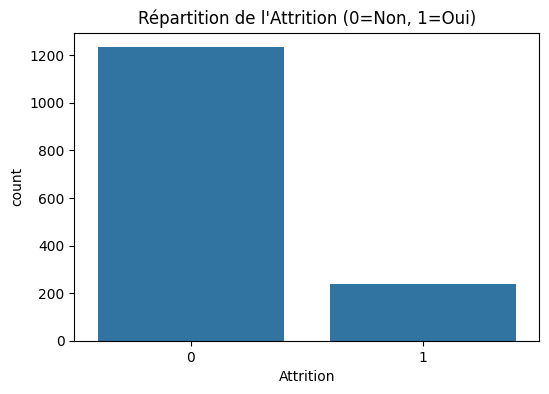

In [169]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df)
plt.title('Répartition de l\'Attrition (0=Non, 1=Oui)')
plt.show()

<p>- Le graphique montre un fort déséquilibre de classe.<br>
 -La majorité des employés restent (0). <br>
 -On SMOTE pour ne pas biaiser le modèle. </p>

In [170]:
df.select_dtypes(include=['int64']).columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

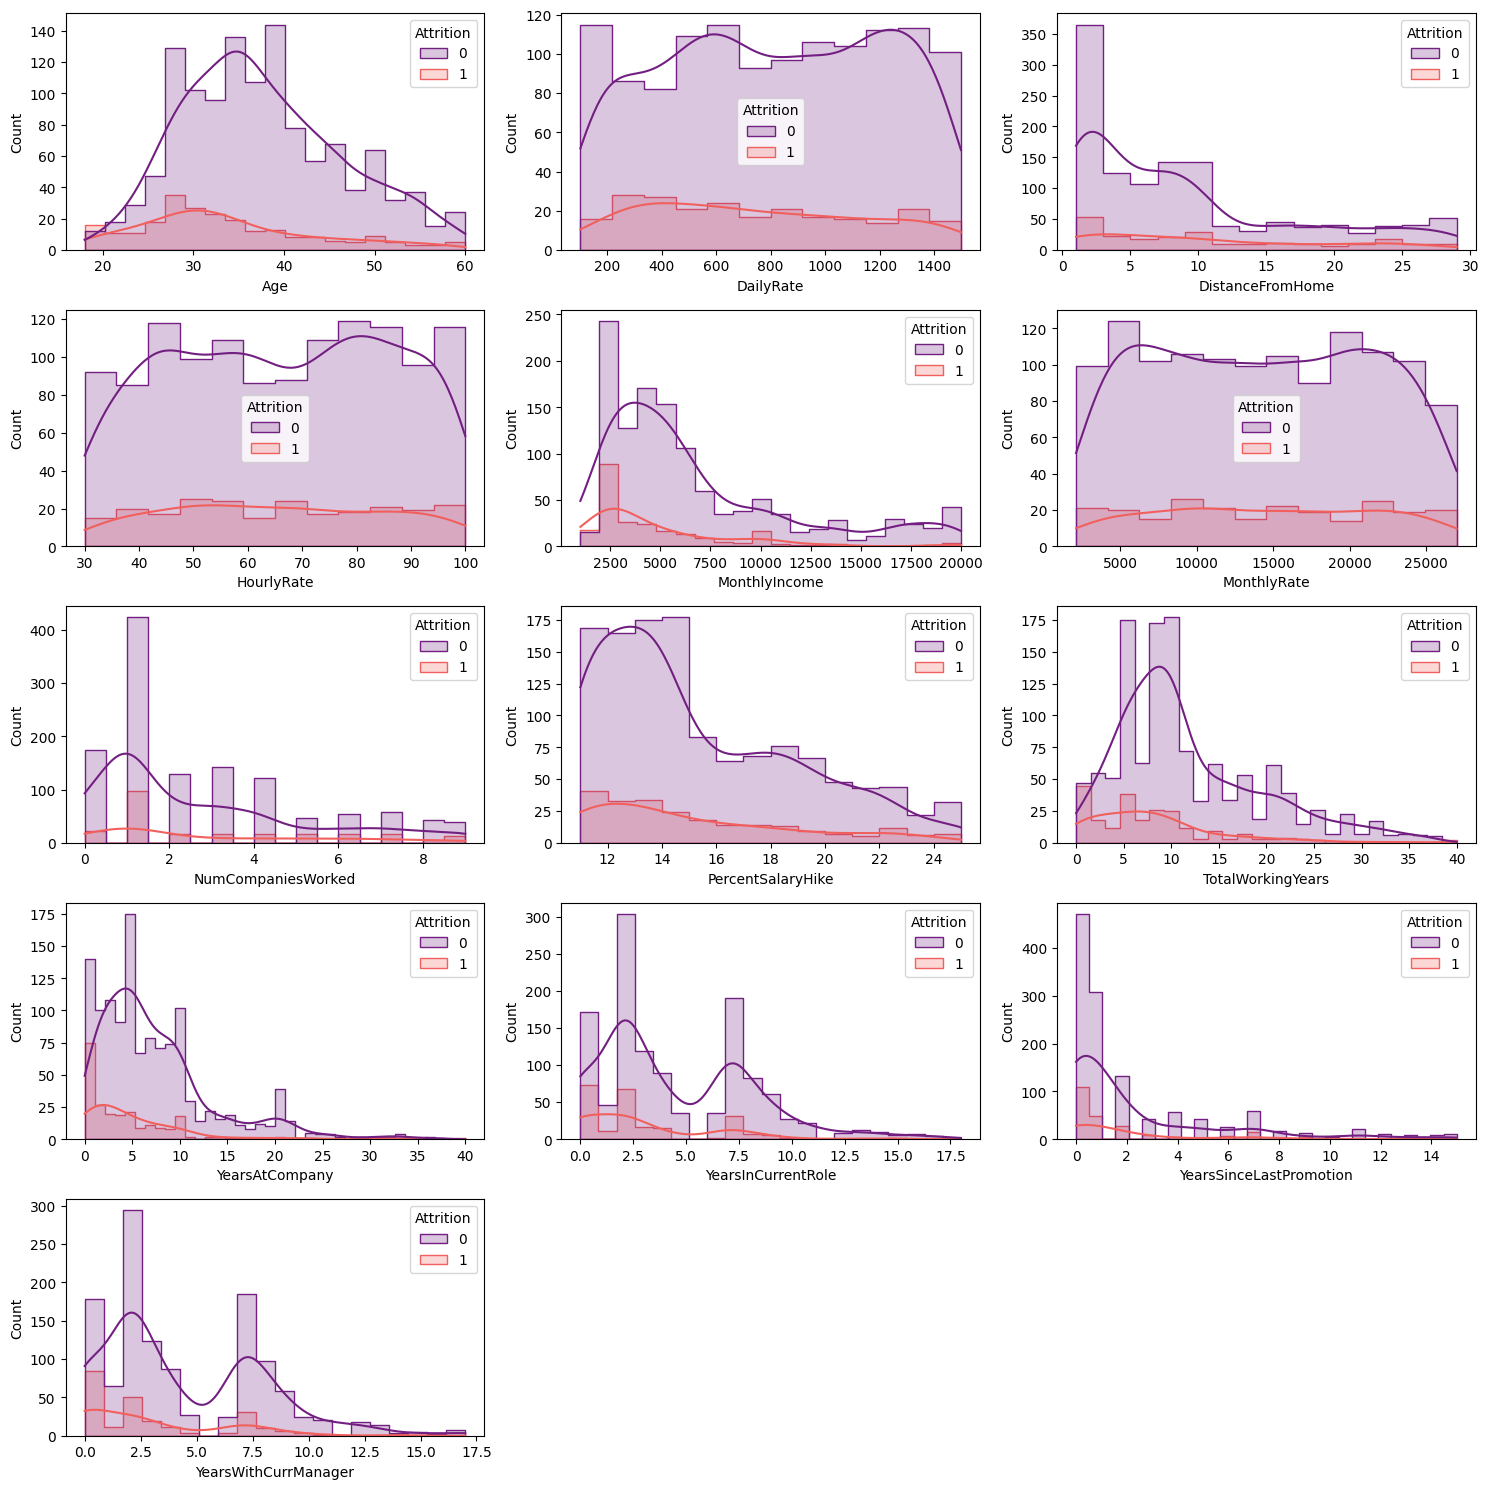

In [171]:
num_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 
            'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 
            'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

# Tracé des Histogrammes par rapport à la cible
plt.figure(figsize=(15, 15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 3, i)
    sns.histplot(data=df, x=col, hue='Attrition', kde=True, palette='magma', element="step")
    # plt.title(f'Influence de : {col}')
plt.tight_layout()
plt.show()

<p> - MonthlyIncome / JobLevel : Très forte influence. Les bas salaires partent massivement.<br>
- DistanceFromHome : On observe un "pic" de départ chez ceux habitant loin (>15km).<br>
- DailyRate / HourlyRate / MonthlyRate : Les distributions sont presque identiques pour Yes/No. <br>
  => Ces variables sont du "bruit" et seront éliminées pour simplifier le modèle.<br>
- Age : Les 25-35 ans sont les plus instables.<br>
</p>

## 3.2 Analyse des Variables Catégorielles et Perception (Barplots)

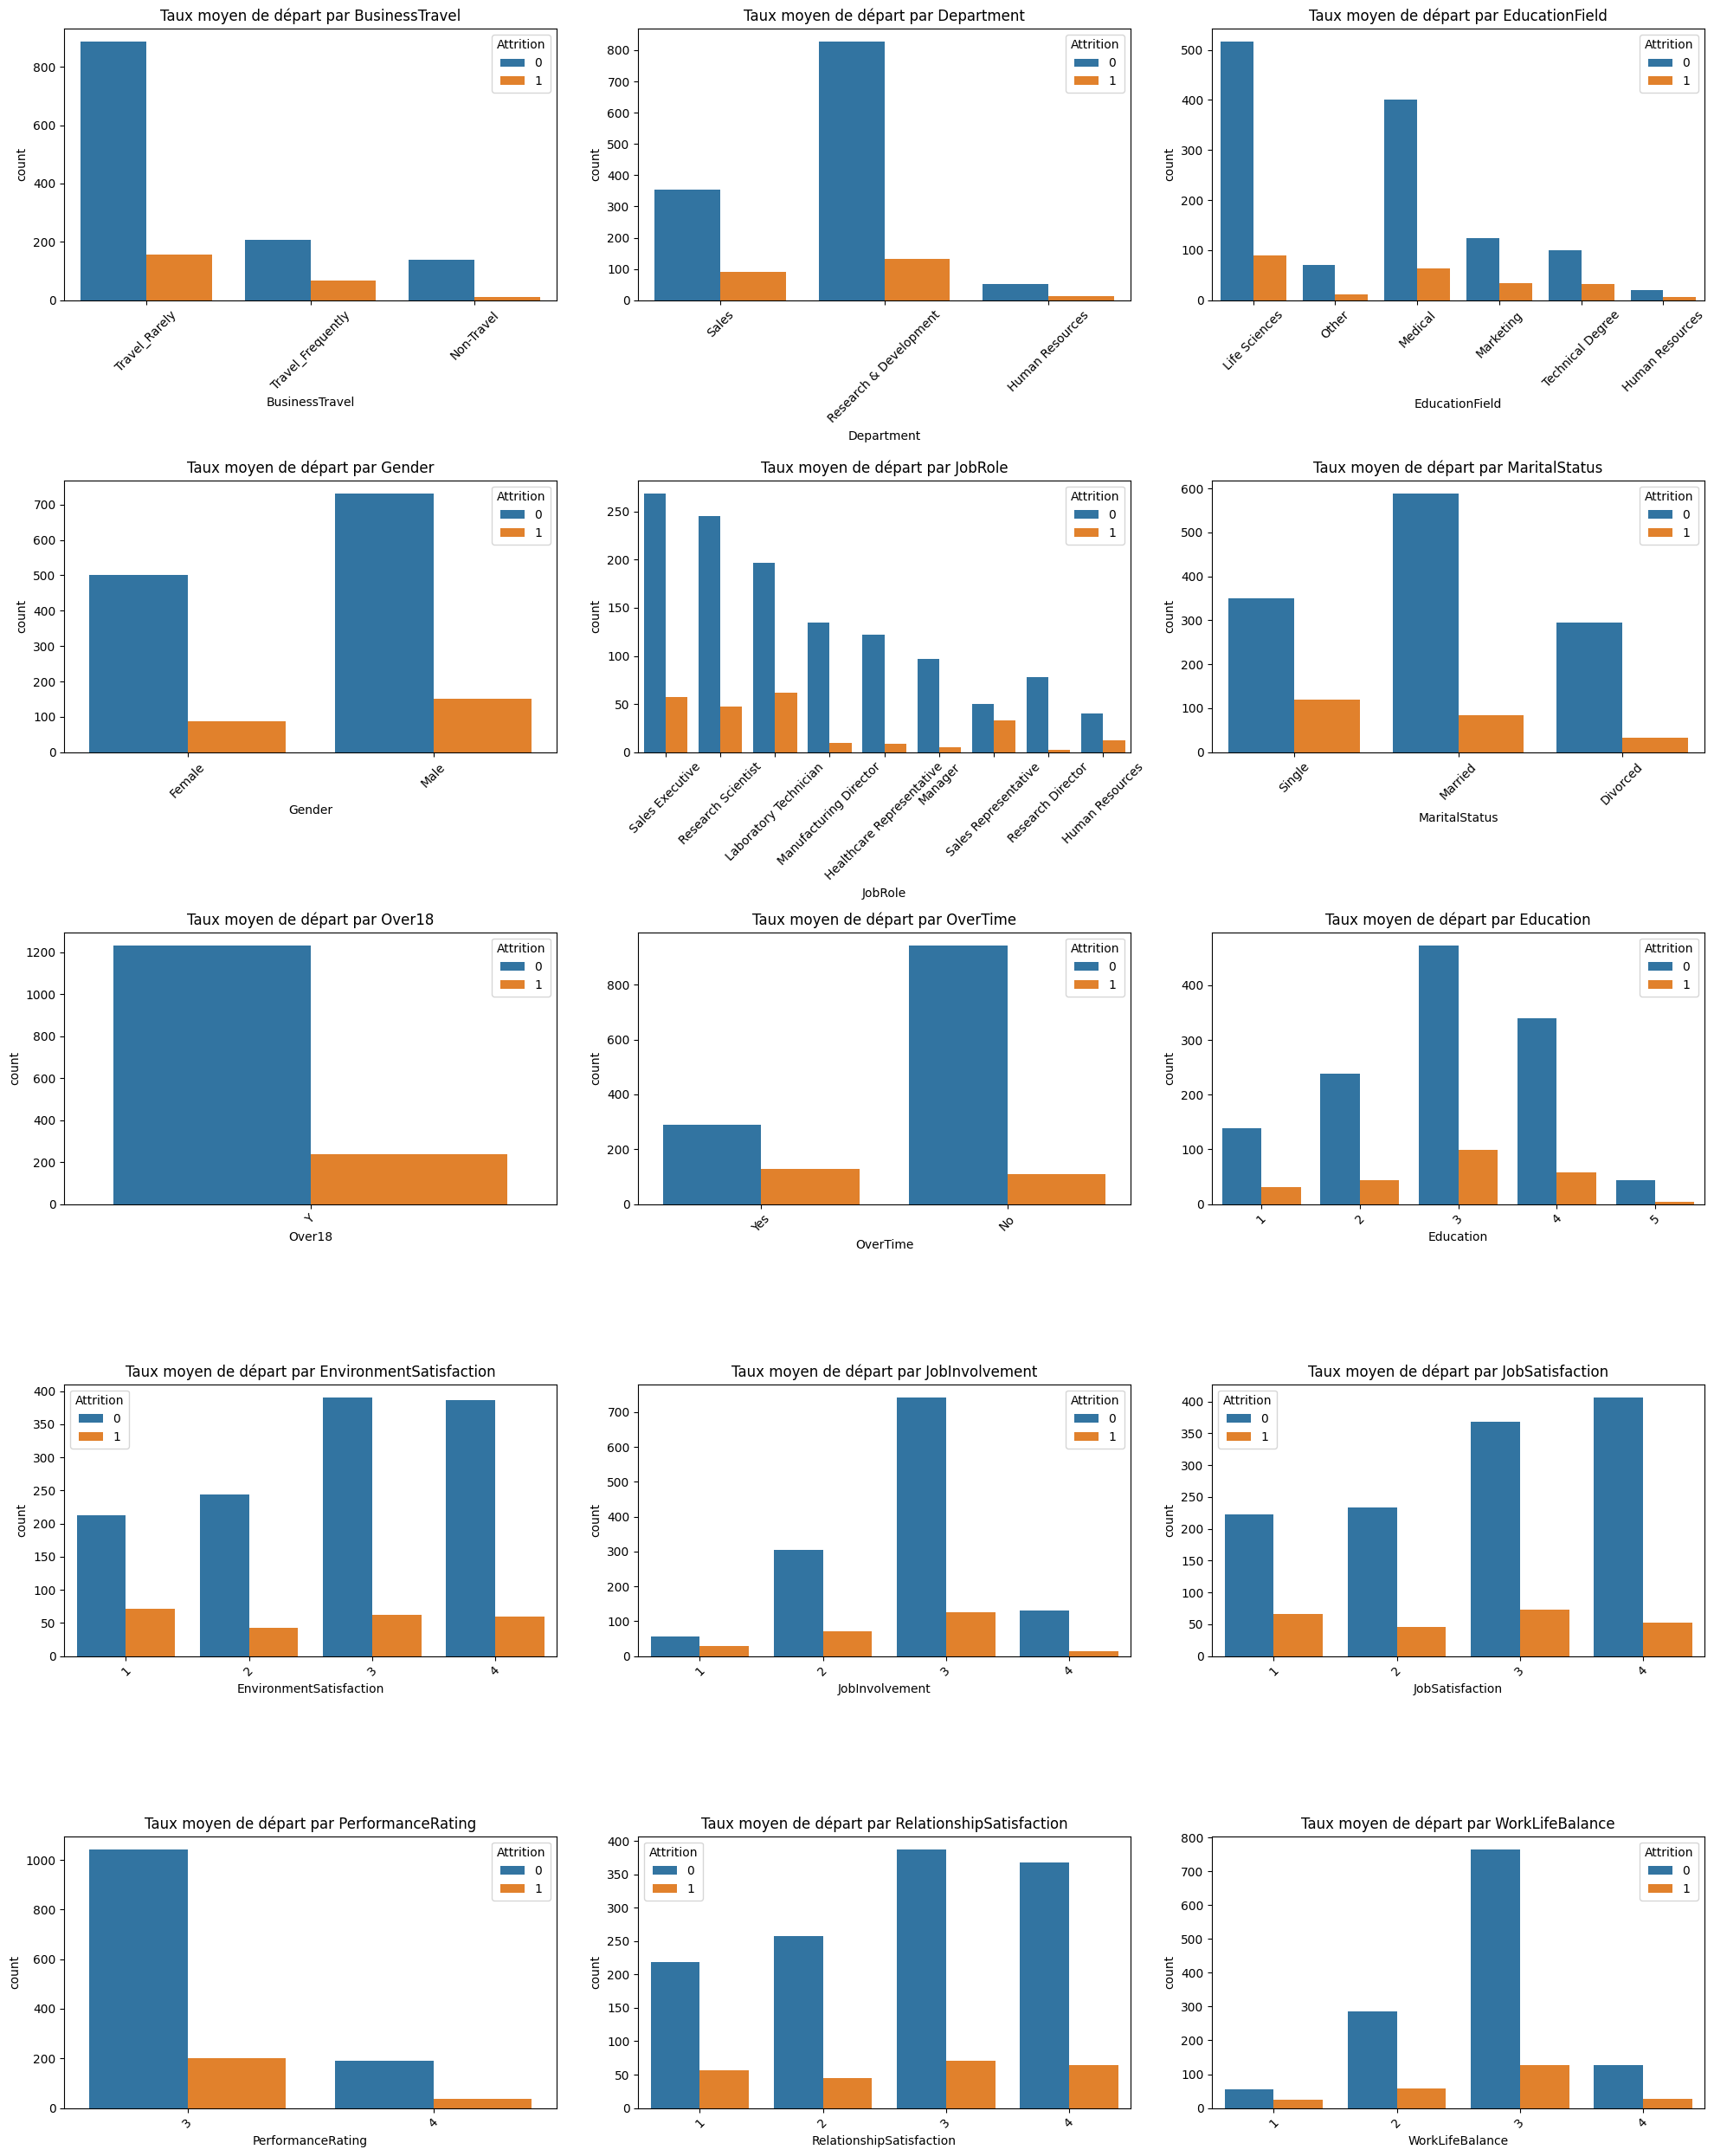

In [172]:
# cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
cat_cols =df.select_dtypes(include=['object'])
fake_num_cols =df[['Education','EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction','PerformanceRating','RelationshipSatisfaction','WorkLifeBalance']]

new_cat_cols = pd.concat([cat_cols,fake_num_cols],axis=1)
new_cat_cols
plt.figure(figsize=(20, 25))
for i, col in enumerate(new_cat_cols, 1):
    plt.subplot(5, 3, i)
    # Calcul du taux de départ moyen par catégorie
    sns.countplot(x=col, hue='Attrition', data=df)
    plt.title(f'Taux moyen de départ par {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<p> 
- OverTime : Facteur CRITIQUE. Ceux qui font des heures supp partent 3x plus.<br>
- MaritalStatus : Les "Single" partent beaucoup plus que les "Divorced/Married".<br>
- BusinessTravel : Les "Frequently Travel" ont un taux de départ record.<br>
- Gender : Très peu de différence entre Male et Female => Variable à faible influence.</p>

## 3.2 Analyse de l'Impact du Revenu et de l'Âge

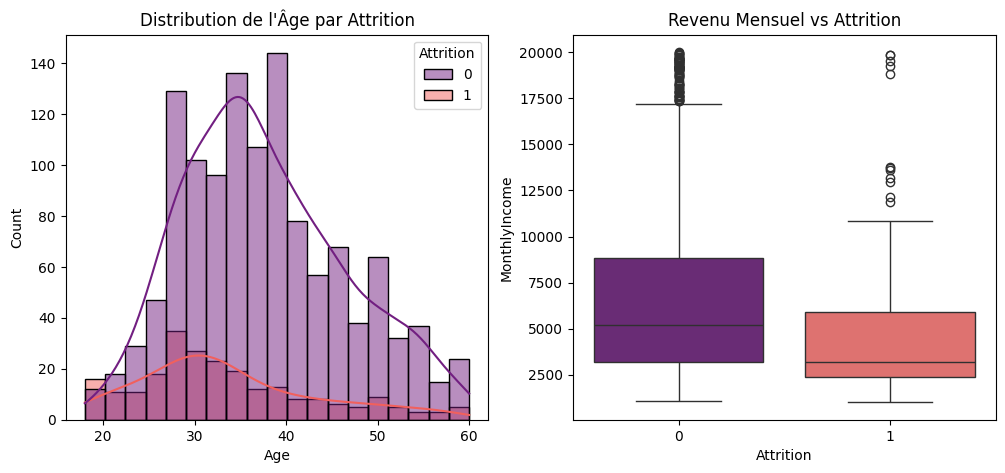

In [174]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, palette='magma')
plt.title('Distribution de l\'Âge par Attrition')

plt.subplot(1, 2, 2)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='magma')
plt.title('Revenu Mensuel vs Attrition')
plt.show()

<p>- Âge : Les départs sont plus fréquents chez les jeunes employés (25-35 ans) <br>
- Revenu : Les employés qui quittent l'entreprise ont une médiane de salaire nettement inférieure <br>
- Le salaire est un levier de rétention majeur </p>

### 3.3 Analyse des Variables de Satisfaction

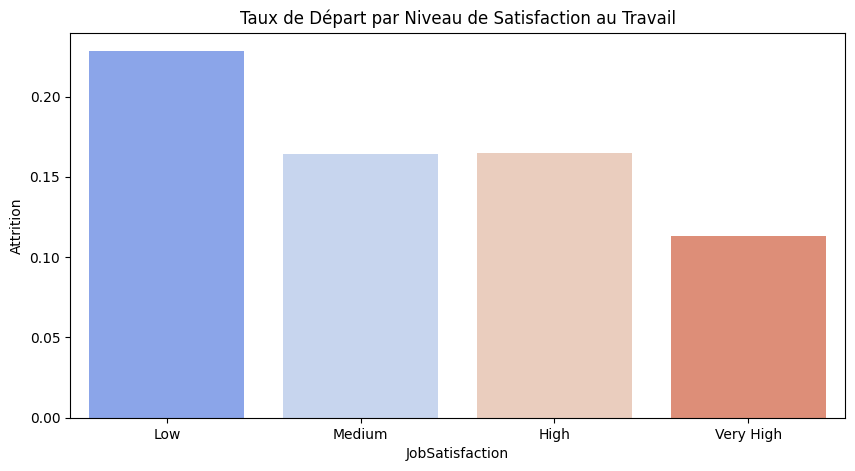

In [175]:
# Utilisation des mappings pour l'interprétation
satisfaction_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}

plt.figure(figsize=(10, 5))
sns.barplot(x='JobSatisfaction', y='Attrition', data=df, ci=None, palette='coolwarm')
plt.xticks(ticks=[0,1,2,3], labels=['Low', 'Medium', 'High', 'Very High'])
plt.title('Taux de Départ par Niveau de Satisfaction au Travail')
plt.show()


<p> plus la satisfaction est "Low", plus la probabilité de départ est élevée </p>

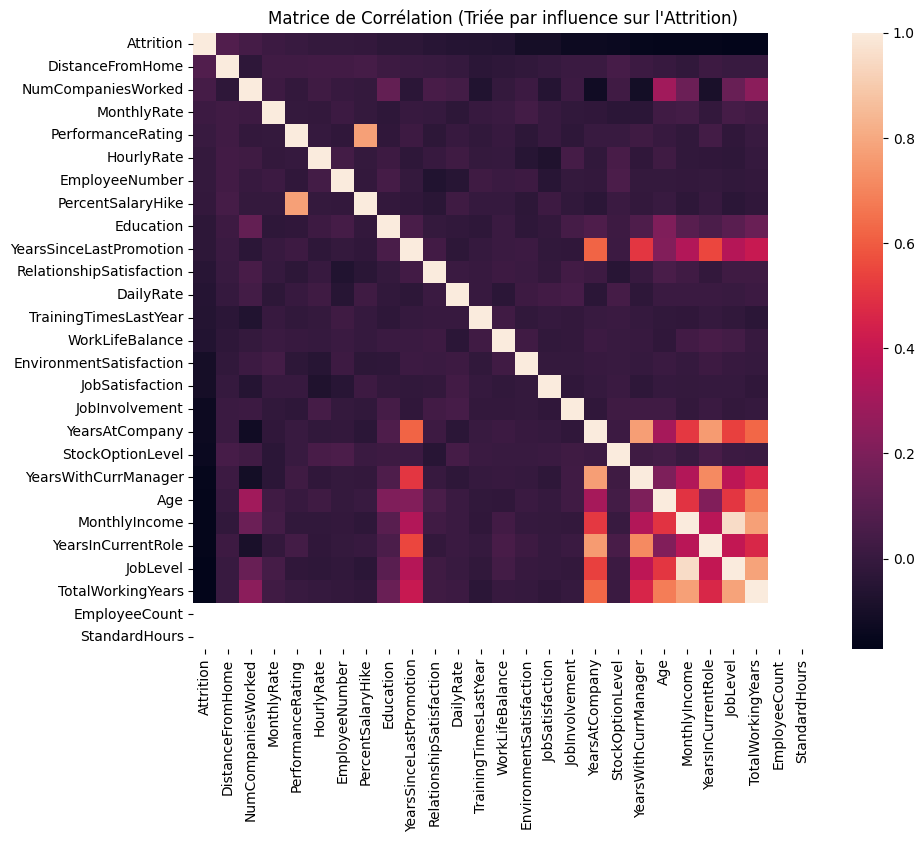

In [ ]:
# Calcul de la corrélation absolue avec Attrition_Num
correlations = df.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)


# On filtre les variables avec une corrélation très faible (< 0.05)
plt.figure(figsize=(10, 8))
sns.heatmap(df[correlations.index].corr(numeric_only=True))
plt.title('Matrice de Corrélation (Triée par influence sur l\'Attrition)')
plt.show()



## 4. PIPELINE DE PREPROCESSING

In [177]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [178]:
# Séparation avec stratification (pour garder les 16% dans les deux sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [179]:
# Définition des types de colonnes
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [180]:
# Pipeline de transformation : Pour éviter la fuite de données et automatiser le traitement.
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## 5. ENTRAÎNEMENT ET COMPARAISON

In [181]:
# On compare deux modèles dans un dictionnaire
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42)
}



In [182]:
for name, model in models.items():
    # Création du pipeline avec SMOTE pour équilibrer les classes
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))


--- LogisticRegression ---
              precision    recall  f1-score   support

           0       0.92      0.80      0.86       247
           1       0.37      0.62      0.46        47

    accuracy                           0.77       294
   macro avg       0.64      0.71      0.66       294
weighted avg       0.83      0.77      0.79       294


--- RandomForest ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.92       247
           1       0.68      0.28      0.39        47

    accuracy                           0.86       294
   macro avg       0.78      0.63      0.66       294
weighted avg       0.85      0.86      0.84       294



## 6. OPTIMISATION ET ÉVALUATION FINALE

In [183]:
#On optimise le Random Forest via GridSearchCV
param_grid = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 10]}
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1')
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentS...
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object'))])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1')

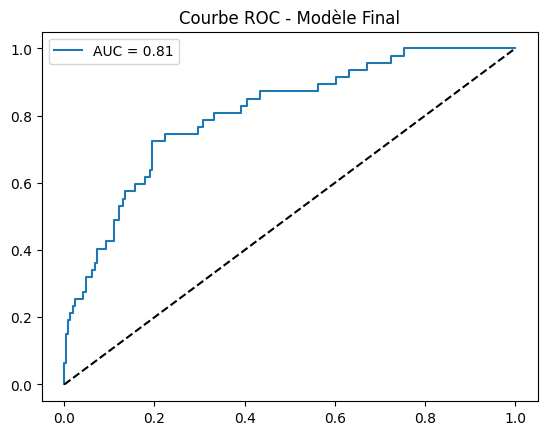

In [184]:
# Courbe ROC

y_probs = grid.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_probs):.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.title('Courbe ROC - Modèle Final')
plt.legend()
plt.show()

In [185]:
# on sauvegarde le pipeline complet, qui contient le préprocessing et le modèle.
model_path = '../ml_model/full_pipeline02.pkl'
joblib.dump(grid.best_estimator_, model_path)

['../ml_model/full_pipeline02.pkl']

In [ ]:
ohjinmj